# LiH/STO-3G bond-stretching VQE energy curve (frozen core)

Goal: repeat the Phase 4 bond-stretching workflow (notebook 02) on
LiH instead of H2, using a frozen-core active space, to see whether
UCCSD stops being exact once the active space has more than one
occupied/virtual orbital pair.

Pipeline, repeated at each bond distance:

1. Define molecular geometry and basis at a given Li-H distance.
2. Use PySCF through Qiskit Nature to obtain the electronic-structure problem.
3. Freeze the Li 1s core orbital (FreezeCoreTransformer).
4. Build the second-quantized fermionic Hamiltonian over the active space.
5. Map the fermionic Hamiltonian to qubits using Jordan-Wigner.
6. Build a Hartree-Fock initial state and UCCSD ansatz over the active space.
7. Run VQE with a classical optimizer (noiseless statevector simulation, SciPy SLSQP).
8. Compare against an exact classical eigensolver reference (in the same active space).

In [1]:
import importlib.metadata as metadata

packages = [
    'qiskit',
    'qiskit-nature',
    'qiskit-algorithms',
    'pyscf',
    'numpy',
    'scipy',
    'matplotlib',
    'pandas',
]

for package in packages:
    try:
        print(f'{package}: {metadata.version(package)}')
    except metadata.PackageNotFoundError:
        print(f'{package}: NOT INSTALLED')


qiskit: 2.5.0
qiskit-nature: 0.8.0
qiskit-algorithms: 0.4.0
pyscf: 2.14.0
numpy: 2.5.1
scipy: 1.18.0
matplotlib: 3.11.1
pandas: 3.0.3


## 1. Active space, before the bond-distance sweep

LiH/STO-3G has 6 spatial orbitals (Li 1s, 2s, 2px, 2py, 2pz; H 1s) and
4 electrons. Freezing the Li 1s core removes 1 spatial orbital and 2
electrons, leaving an active space of 5 spatial orbitals and 2
electrons (1 alpha, 1 beta). We check this once at the experimental
equilibrium distance (1.5949 A) before running the full grid.

In [2]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer

_check_driver = PySCFDriver(
    atom='Li 0 0 0; H 0 0 1.5949',
    unit=DistanceUnit.ANGSTROM,
    charge=0,
    spin=0,
    basis='sto3g',
)
_full_problem = _check_driver.run()
print(f'Full space: {_full_problem.num_spatial_orbitals} spatial orbitals, '
      f'{_full_problem.num_particles} particles (alpha, beta)')

_freeze_core_transformer = FreezeCoreTransformer(freeze_core=True)
_active_problem = _freeze_core_transformer.transform(_full_problem)
print(f'Frozen-core active space: {_active_problem.num_spatial_orbitals} spatial orbitals, '
      f'{_active_problem.num_particles} particles (alpha, beta)')


Full space: 6 spatial orbitals, (2, 2) particles (alpha, beta)
Frozen-core active space: 5 spatial orbitals, (1, 1) particles (alpha, beta)


## 2. Bond-distance grid

We sweep the Li-H distance from compressed, through the experimental
equilibrium (1.5949 A), to strongly stretched (6.0 A).

In [3]:
bond_lengths_angstrom = [
    1.0, 1.2, 1.4, 1.5949, 1.8, 2.1, 2.5, 3.0, 3.5, 4.5, 6.0,
]
basis = 'sto3g'

print(f'Number of bond distances: {len(bond_lengths_angstrom)}')
print(f'Range: {min(bond_lengths_angstrom)} A to {max(bond_lengths_angstrom)} A')


Number of bond distances: 11
Range: 1.0 A to 6.0 A


## 3. Helper function: one bond distance, full pipeline

Same structure as notebook 02's helper, with one addition: the
fermionic Hamiltonian is built after applying `FreezeCoreTransformer`,
so every downstream quantity (spin orbitals, qubits, Pauli terms,
ansatz) reflects the active space, not the full LiH/STO-3G space.

In [4]:
import numpy as np
from scipy.optimize import minimize

from qiskit import transpile
from qiskit.quantum_info import Statevector
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD


def run_lih_sto3g_point(bond_length_angstrom, basis='sto3g'):
    """Run the frozen-core LiH/STO-3G VQE pipeline at a single Li-H bond distance."""
    driver = PySCFDriver(
        atom=f'Li 0 0 0; H 0 0 {bond_length_angstrom}',
        unit=DistanceUnit.ANGSTROM,
        charge=0,
        spin=0,
        basis=basis,
    )
    full_problem = driver.run()

    freeze_core_transformer = FreezeCoreTransformer(freeze_core=True)
    problem = freeze_core_transformer.transform(full_problem)

    fermionic_op = problem.hamiltonian.second_q_op()

    mapper = JordanWignerMapper()
    qubit_op = mapper.map(fermionic_op)

    # Exact classical reference within the active space, possible here because
    # the frozen-core active space is still small enough (10 qubits) to diagonalize.
    hamiltonian_matrix = qubit_op.to_matrix()
    electronic_eigenvalues = np.linalg.eigvalsh(hamiltonian_matrix)
    exact_electronic_energy = float(np.min(electronic_eigenvalues).real)
    exact_energy = exact_electronic_energy + float(problem.nuclear_repulsion_energy)

    initial_state = HartreeFock(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
    )
    ansatz = UCCSD(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
        initial_state=initial_state,
    )

    history = []

    def energy_from_parameters(parameters):
        bound_circuit = ansatz.assign_parameters(parameters, inplace=False)
        # Statevector.from_instruction is exact either way, but on the raw
        # ansatz (opaque multi-qubit excitation gates) it goes through a
        # generic sparse matrix-exponential path that measured at ~17s per
        # call for this 24-parameter/10-qubit ansatz. Transpiling to a plain
        # gate basis first lets Statevector apply gates directly instead,
        # cutting this to ~0.3s per call (~50x) with no change in the result.
        transpiled_circuit = transpile(
            bound_circuit, basis_gates=['u3', 'cx'], optimization_level=1,
        )
        state = Statevector.from_instruction(transpiled_circuit)
        electronic_energy = np.real(state.expectation_value(qubit_op))
        total_energy = electronic_energy + float(problem.nuclear_repulsion_energy)
        history.append(float(total_energy))
        return float(total_energy)

    initial_point = np.zeros(ansatz.num_parameters)

    opt_result = minimize(
        energy_from_parameters,
        initial_point,
        method='SLSQP',
        options={'maxiter': 1000, 'ftol': 1e-10},
    )

    vqe_energy = float(opt_result.fun)
    abs_error = abs(vqe_energy - exact_energy)

    return {
        'bond_length_angstrom': bond_length_angstrom,
        'active_spatial_orbitals': problem.num_spatial_orbitals,
        'active_electrons': sum(problem.num_particles),
        'spin_orbitals': 2 * problem.num_spatial_orbitals,
        'qubits': qubit_op.num_qubits,
        'pauli_terms': len(qubit_op),
        'ansatz_parameters': ansatz.num_parameters,
        'exact_energy_hartree': exact_energy,
        'vqe_energy_hartree': vqe_energy,
        'abs_error_hartree': abs_error,
        'optimizer_success': bool(opt_result.success),
        'optimizer_message': str(opt_result.message),
        'num_function_evaluations': len(history),
    }


## 4. Look at the ansatz once, at equilibrium

Unlike H2/STO-3G, the frozen-core LiH active space has 5 spatial
orbitals (1 occupied, 4 virtual) instead of 1-occupied/1-virtual, so
UCCSD has many more singles and doubles excitations to draw on here.

In [5]:
_driver = PySCFDriver(
    atom='Li 0 0 0; H 0 0 1.5949',
    unit=DistanceUnit.ANGSTROM,
    charge=0,
    spin=0,
    basis=basis,
)
_problem = _freeze_core_transformer.transform(_driver.run())
_mapper = JordanWignerMapper()

_initial_state = HartreeFock(
    num_spatial_orbitals=_problem.num_spatial_orbitals,
    num_particles=_problem.num_particles,
    qubit_mapper=_mapper,
)
_ansatz = UCCSD(
    num_spatial_orbitals=_problem.num_spatial_orbitals,
    num_particles=_problem.num_particles,
    qubit_mapper=_mapper,
    initial_state=_initial_state,
)

print(f'Ansatz: {_ansatz.__class__.__name__}')
print(f'Number of qubits in ansatz: {_ansatz.num_qubits}')
print(f'Number of variational parameters: {_ansatz.num_parameters}')


Ansatz: UCCSD
Number of qubits in ansatz: 10
Number of variational parameters: 24


## 5. Run the energy curve

Now we repeat the full pipeline at every bond distance in the grid and
collect the results into a table.

In [6]:
import pandas as pd

results = []
for bond_length_angstrom in bond_lengths_angstrom:
    print(f'Running bond distance {bond_length_angstrom} A ...')
    point_result = run_lih_sto3g_point(bond_length_angstrom, basis=basis)
    results.append(point_result)

results_df = pd.DataFrame(results)
print()
print(f'Completed {len(results_df)} bond distances.')


Running bond distance 1.0 A ...


Running bond distance 1.2 A ...


Running bond distance 1.4 A ...


Running bond distance 1.5949 A ...


Running bond distance 1.8 A ...


...

Running bond distance 3.0 A ...


Running bond distance 3.5 A ...


Running bond distance 4.5 A ...


Running bond distance 6.0 A ...



Completed 11 bond distances.


## 6. Results table

A compact view of the key quantities at every bond distance.

In [7]:
display_columns = [
    'bond_length_angstrom',
    'active_spatial_orbitals',
    'active_electrons',
    'qubits',
    'pauli_terms',
    'ansatz_parameters',
    'exact_energy_hartree',
    'vqe_energy_hartree',
    'abs_error_hartree',
    'optimizer_success',
    'num_function_evaluations',
]

with pd.option_context('display.float_format', lambda v: f'{v:.10f}'):
    print(results_df[display_columns].to_string(index=False))


 bond_length_angstrom  active_spatial_orbitals  active_electrons  qubits  pauli_terms  ansatz_parameters  exact_energy_hartree  vqe_energy_hartree  abs_error_hartree  optimizer_success  num_function_evaluations
         1.0000000000                        5                 2      10          276                 24          0.4132950834        0.4132950835       0.0000000000               True                       227
         1.2000000000                        5                 2      10          276                 24          0.1655317739        0.1655317739       0.0000000000               True                       227
         1.4000000000                        5                 2      10          276                 24          0.0125608308        0.0125608308       0.0000000000               True                       227
         1.5949000000                        5                 2      10          276                 24         -0.0838432366       -0.0838432366       0.0

## 7. Plot: energy curve and VQE error

Top panel: exact diagonalization energy and VQE energy versus Li-H
bond distance. Bottom panel: absolute VQE error versus bond distance,
on a log scale.

Saved figure to ../figures/lih_energy_curve_frozen_core.png


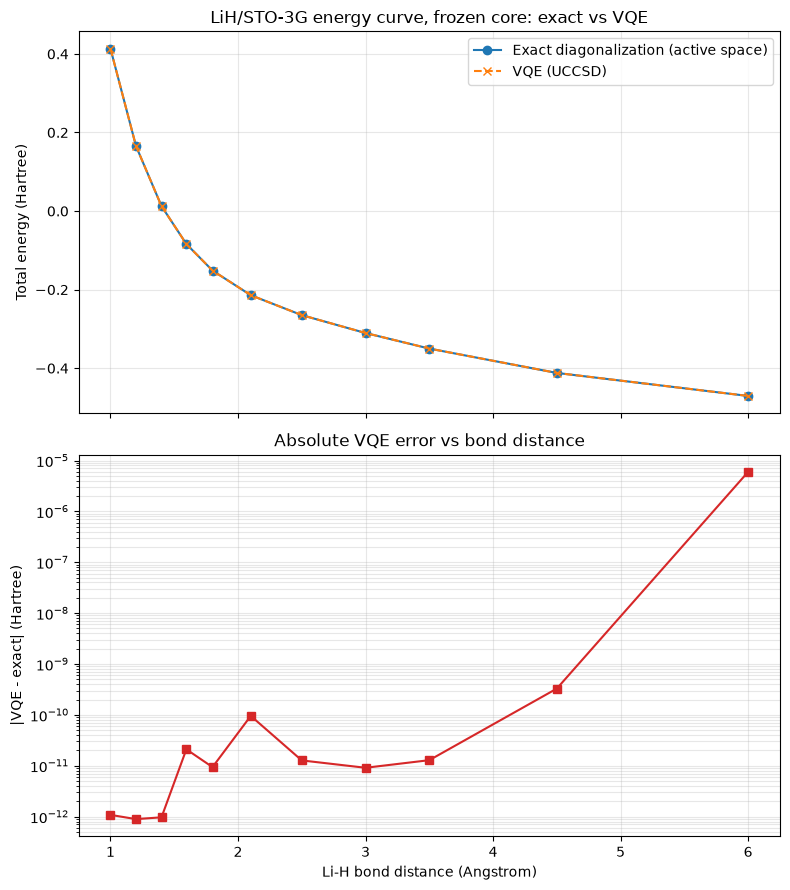

In [8]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, (ax_energy, ax_error) = plt.subplots(2, 1, figsize=(8, 9), sharex=True)

ax_energy.plot(
    results_df['bond_length_angstrom'],
    results_df['exact_energy_hartree'],
    'o-', label='Exact diagonalization (active space)',
)
ax_energy.plot(
    results_df['bond_length_angstrom'],
    results_df['vqe_energy_hartree'],
    'x--', label='VQE (UCCSD)',
)
ax_energy.set_ylabel('Total energy (Hartree)')
ax_energy.set_title('LiH/STO-3G energy curve, frozen core: exact vs VQE')
ax_energy.legend()
ax_energy.grid(True, alpha=0.3)

ax_error.semilogy(
    results_df['bond_length_angstrom'],
    results_df['abs_error_hartree'],
    's-', color='tab:red',
)
ax_error.set_xlabel('Li-H bond distance (Angstrom)')
ax_error.set_ylabel('|VQE - exact| (Hartree)')
ax_error.set_title('Absolute VQE error vs bond distance')
ax_error.grid(True, alpha=0.3, which='both')

fig.tight_layout()

# Notebook kernels default to the notebook's own directory as cwd,
# so the repo-root figures/ directory is one level up.
figure_path = Path('..') / 'figures' / 'lih_energy_curve_frozen_core.png'
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=150)
print(f'Saved figure to {figure_path}')

plt.show()


## 8. Scientific interpretation

- Freezing the Li 1s core reduces LiH/STO-3G from 4 electrons in 6
  spatial orbitals down to an active space of **2 electrons in 5
  spatial orbitals** (1 occupied, 4 virtual).
- This is a genuinely different orbital structure than H2/STO-3G (1
  occupied, 1 virtual): UCCSD now has many more possible single and
  double excitations to draw on, reflected in the much larger
  parameter count of the ansatz built above.
- However: with only 2 active electrons, singles and doubles are the
  *only* excitations that exist. A determinant can't be triply or
  quadruply excited if there are only 2 electrons to redistribute. So
  CISD (classically) and UCCSD (here) are still mathematically
  equivalent to full CI in this active space, for the same structural
  reason as H2 (no excitation levels beyond doubles exist to be
  missing) even though the orbital count grew.
- If the results table above shows `abs_error_hartree` at
  floating-point round-off across the whole curve (as it did for
  H2/STO-3G), that is the expected outcome given the above, not a
  surprise or a bug: freezing the core all the way down to 2 active
  electrons removes the thing (3+ active electrons) needed for UCCSD
  to become a genuine truncated approximation.
- This directly answers the open question carried over from
  `notes/uccsd_classical_vs_quantum.md`: yes, freezing the core on LiH
  can make UCCSD exact for the wrong reason (too few active electrons),
  independent of how many virtual orbitals are in the active space.
- To actually see UCCSD deviate from full CI, the active space needs
  at least 3-4 active electrons, e.g. LiH without freezing the core, or
  a molecule/basis where the frozen-core active space still leaves 4+
  electrons active.

## Limitations

1. This is an ideal statevector simulation, not a hardware calculation.
2. No sampling noise, device noise, decoherence, or transpilation constraints are included.
3. Exact diagonalization is only possible here because the frozen-core active space is small (10 qubits, 1024x1024 matrix).
4. Jordan-Wigner is used throughout; no qubit-reduction mapping or symmetry tapering is applied.
5. The frozen-core approximation itself is not validated against the non-frozen 4-electron result in this notebook (see next step).
6. The optimizer is restarted from the same all-zero initial point at each bond distance; no warm-starting from a neighboring point.
7. As argued above, this active space (2 active electrons) is not expected to be a genuine test of UCCSD truncation error; a follow-up notebook without core freezing (4 active electrons) is needed for that.